# Phase 4 — Hyperparameter tuning + error analysis (Robotic Grasp Prediction)

**Project:** Cornell Grasping Dataset · ResNet-18 grasp regressor · object-wise split (folder 03 held out)
**Date:** 2026-05-28 · **Session 4 of 7**

Phase 3 climbed from the Phase-2 ceiling (0.550 object-wise) to **0.770** with the *E3.5 stack*: full 785-image
training set + rotation aug (±30°) + depth-as-blue + multi-positive closest-GT loss. That beat Lenz 2014 (0.739)
and GG-CNN 2018 (0.73) but landed **8 pp short of Redmon 2015 (0.849)**.

Four pre-registered questions for today:

1. **Can an Optuna sweep on the E3.5 stack close the 8-pp gap to Redmon 2015?** Search `lr, weight_decay,
   rotation_deg, batch_size`. *Crucial methodology:* we tune on a **held-out validation folder (07)**, never on
   the test folder (03), then evaluate the winner on test exactly once — so any gain is real, not test-set overfitting.
2. **Depth-as-blue HURT in Phase 3 (-2 pp). Was the depth signal useless, or was it masked by destroying the blue
   colour channel?** Test depth as a genuine **4th input channel** (conv1 re-initialised), keeping all three RGB channels.
3. **How does the model do on the easier image-wise split?** Direct comparison to Lenz 2014 (0.756) / Redmon 2015 (0.844) image-wise.
4. **Where do the remaining errors live?** Phase 3's dominant failure was "angle-ok / IoU-too-low" (localisation).
   Decompose the tuned champion's failures and compare to E3.5.

**Primary metric** (fixed in Phase 1): Jiang et al. 2011 rectangle metric — a grasp is correct iff there exists a GT
positive with **IoU > 0.25 AND angle error < 30 deg**. It is the field standard reported by every Cornell benchmark, so
it makes our numbers directly comparable to the published leaderboard.

In [1]:
import os, sys, json, math, time, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import optuna

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from cornell import load_samples, is_correct_jiang, iou as poly_iou, angle_diff_deg
from dataset import decode_prediction
from dataset_phase3 import (CornellGraspDatasetP3, object_wise_split, image_wise_split,
                            prewarm_depth_cache)
from dataset_phase4 import CornellGraspDatasetP4
from torch_models import ResNet18Regressor, count_params
from models_phase4 import ResNet18Regressor4ch
from trainer_phase3 import train_regression_p3, _pick_device

DEVICE = _pick_device()
SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- search/eval budget --------------------------------------------------
PROXY_EPOCHS  = 15     # cheap proxy budget per Optuna trial (ranks configs)
N_TRIALS      = 18
STUDY_TIMEOUT = 2400   # hard wall-clock guard so the cell stays < 1h timeout
FINAL_EPOCHS  = 40     # tuned-champion retrain budget (a-priori, fixed before test eval)
print(f'device={DEVICE}  torch={torch.__version__}  optuna={optuna.__version__}')
print(f'ROOT={ROOT}')

device=mps  torch=2.8.0  optuna=4.8.0
ROOT=/Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Robotic-Grasp-Prediction


## 1 - Data and splits

The clean tuning protocol uses **three disjoint object-wise partitions**:

| Partition | Folders | n | Used for |
|---|---|---:|---|
| **TEST** | 03 | 100 | held out; touched once, for the final tuned-champion number (same as Phase 2/3) |
| **VAL** | 07 | 100 | Optuna objective - the score every trial optimises |
| **SEARCH-TRAIN** | 01,02,04,05,06,08,09,10 | 685 | trains each Optuna trial |
| **FULL-TRAIN** | everything except 03 | 785 | final retrain of the winning config (matches Phase-3's E3.5 training set exactly) |

Holding 07 out *object-wise* (not a random row split) means no object in VAL is seen in SEARCH-TRAIN, so the
validation signal generalises the same way the test signal does - the whole point of an object-wise benchmark.

In [2]:
samples = load_samples(ROOT / 'data/raw/cornell/extracted')
by_folder = Counter(s.object_id for s in samples)
print(f'Total images: {len(samples)}  per-folder: {dict(sorted(by_folder.items()))}')

TEST_FOLDERS = [3]
VAL_FOLDERS  = [7]

non_test, test_set = object_wise_split(samples, TEST_FOLDERS)     # 785 / 100
search_train, val_set = object_wise_split(non_test, VAL_FOLDERS)  # 685 / 100
full_train = non_test                                             # 785 (incl. folder 07)

print(f'TEST (folder 03):        {len(test_set)}')
print(f'VAL  (folder 07):        {len(val_set)}')
print(f'SEARCH-TRAIN:            {len(search_train)}')
print(f'FULL-TRAIN (excl. 03):   {len(full_train)}')

t0 = time.time()
n_cached = prewarm_depth_cache(samples)   # warm ALL depth maps once (~3 min)
print(f'depth cache warmed: {n_cached} maps in {time.time()-t0:.1f}s')

Total images: 885  per-folder: {1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 50, 10: 35}
TEST (folder 03):        100
VAL  (folder 07):        100
SEARCH-TRAIN:            685
FULL-TRAIN (excl. 03):   785


depth cache warmed: 885 maps in 255.9s


## 2 - Baseline recap

Everything today is measured against the Phase-3 leaderboard. The number to beat on the **object-wise test (folder 03)** is **E3.5 = 0.770**.

In [3]:
metrics_path = ROOT / 'results/metrics.json'
M = json.loads(metrics_path.read_text())
p3 = M['phase_3']['experiments']
P2_M2 = 0.550   # Phase-2 ResNet-18 ceiling (200-img train)
E35_ACC = p3['E3.5_all_knobs']['accuracy']
print('Phase-3 object-wise leaderboard (test = folder 03):')
base_rows = []
for k, v in p3.items():
    base_rows.append({'experiment': k, 'accuracy': v['accuracy'],
                      'median_iou': v['median_iou'], 'median_angle_err': v['median_angle_err_deg']})
base_df = pd.DataFrame(base_rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
print(base_df.to_string(index=False))
print(f'\nTarget to beat: E3.5 = {E35_ACC:.3f}   | Redmon 2015 obj-wise = 0.849 (the 8-pp gap)')

Phase-3 object-wise leaderboard (test = folder 03):
     experiment  accuracy  median_iou  median_angle_err
 E3.5_all_knobs      0.77    0.403600          4.912155
 E3.1_full_data      0.73    0.405309         10.475589
 E3.4_multi_pos      0.73    0.428433          5.379198
E3.3_depth_blue      0.71    0.420175          9.912234
   E3.2_rot_aug      0.70    0.369032          7.991417

Target to beat: E3.5 = 0.770   | Redmon 2015 obj-wise = 0.849 (the 8-pp gap)


## 3 - Evaluation + failure-decomposition utilities

`evaluate_p3` returns the Jiang accuracy plus per-sample IoU/angle so we can decompose *why* the model fails. It
supports both depth injection styles (depth-as-blue for the E3.5 stack, depth-as-4th-channel for the Phase-4 test).
`failure_decompose` buckets every wrong prediction into the three diagnostic clusters from Phase 3.

In [4]:
@torch.no_grad()
def evaluate_p3(model, samp, *, use_depth_blue=False, use_depth_4ch=False):
    model = model.to(DEVICE).eval()
    if use_depth_4ch:
        ds = CornellGraspDatasetP4(samp, augment=False, use_depth_4ch=True)
    else:
        ds = CornellGraspDatasetP3(samp, augment=False, use_depth_blue=use_depth_blue,
                                   multi_positive=False)
    loader = DataLoader(ds, batch_size=1, shuffle=False)
    correct = 0; total = 0; ious = []; angs = []; per = []
    t0 = time.time()
    for x, _t, idx in loader:
        x = x.to(DEVICE); idx = int(idx.item()); s = ds.samples[idx]
        pred = model(x).cpu().numpy()[0]
        rect = decode_prediction(pred)
        ok = is_correct_jiang(rect, s.positives, 0.25, 30.0)
        cands = [(poly_iou(rect, g), angle_diff_deg(rect, g)) for g in s.positives]
        best = max(cands, key=lambda t: t[0]) if cands else (0.0, 90.0)
        ious.append(best[0]); angs.append(best[1])
        per.append({'pcd_id': s.pcd_id, 'object_id': s.object_id, 'correct': int(ok),
                    'best_iou': float(best[0]), 'best_angle_err': float(best[1])})
        correct += int(ok); total += 1
    return {'n': total, 'accuracy': correct / max(total, 1),
            'median_iou': float(np.median(ious)), 'median_angle_err_deg': float(np.median(angs)),
            'inference_ms_per_image': 1000.0 * (time.time()-t0)/max(total,1), 'per_sample': per}

def failure_decompose(per_sample, iou_thresh=0.25, ang_thresh=30.0):
    c = Counter()
    for r in per_sample:
        if r['correct']:
            continue
        iou_ok = r['best_iou'] > iou_thresh
        ang_ok = r['best_angle_err'] <= ang_thresh
        if ang_ok and not iou_ok:   c['angle_ok_iou_low']  += 1
        elif iou_ok and not ang_ok: c['iou_ok_angle_wrong'] += 1
        else:                       c['both_wrong']         += 1
    return dict(c)

print('utilities defined')

utilities defined


## 3b - Optuna search design

- **Search space:** `lr` in [3e-4, 3e-3] (log), `weight_decay` in [1e-5, 1e-3] (log), `rotation_deg` in {15,30,45}, `batch_size` in {16,32,64}.
- **Fixed E3.5 stack** in every trial: depth-as-blue ON, multi-positive closest-GT loss ON.
- **Objective:** maximise **VAL (folder 07) Jiang accuracy** after a cheap `PROXY_EPOCHS`-epoch train on SEARCH-TRAIN.
- **Why a proxy budget?** A full E3.5 train is ~6 min; a real sweep would blow the cell timeout. 15 epochs ranks
  configurations cheaply; the winner is then retrained at the full `FINAL_EPOCHS`. We do *not* search epochs in the
  proxy (a fixed proxy budget makes trials comparable); epochs is set a-priori to 40 for the final retrain.
- **TPESampler(seed=42)** for reproducibility; a hard `STUDY_TIMEOUT` wall-clock guard caps the cell.

**Caveat we will check:** the objective is a 0/1 accuracy over 100 VAL images, so its resolution is 1 pp and it is
noisy. We will inspect whether Optuna actually separates configs or just chases noise (median IoU is the smoother tie-breaker).

In [5]:
def make_train_loader(samp, *, rot, bs, depth_blue=True, depth_4ch=False, multi_pos=True):
    if depth_4ch:
        ds = CornellGraspDatasetP4(samp, augment=True, augment_rot_deg=rot,
                                   use_depth_4ch=True, multi_positive=multi_pos, seed=SEED)
    else:
        ds = CornellGraspDatasetP3(samp, augment=True, augment_rot_deg=rot,
                                   use_depth_blue=depth_blue, multi_positive=multi_pos, seed=SEED)
    return DataLoader(ds, batch_size=bs, shuffle=True, num_workers=0, drop_last=False)

def fit_e35(train_samp, *, lr, wd, rot, bs, epochs, depth_blue=True, depth_4ch=False,
            multi_pos=True, pretrained=True):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    loader = make_train_loader(train_samp, rot=rot, bs=bs, depth_blue=depth_blue,
                               depth_4ch=depth_4ch, multi_pos=multi_pos)
    model = (ResNet18Regressor4ch(out_dim=6, pretrained=pretrained) if depth_4ch
             else ResNet18Regressor(out_dim=6, pretrained=pretrained))
    res = train_regression_p3(model, loader, epochs=epochs, lr=lr, weight_decay=wd,
                              multi_positive=multi_pos, device=DEVICE)
    return model, res

_trial_log = []
def objective(trial):
    lr  = trial.suggest_float('lr', 3e-4, 3e-3, log=True)
    wd  = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    rot = trial.suggest_categorical('rotation_deg', [15, 30, 45])
    bs  = trial.suggest_categorical('batch_size', [16, 32, 64])
    t0 = time.time()
    model, _ = fit_e35(search_train, lr=lr, wd=wd, rot=rot, bs=bs, epochs=PROXY_EPOCHS)
    m = evaluate_p3(model, val_set, use_depth_blue=True)
    del model
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    rec = {'trial': trial.number, 'lr': lr, 'weight_decay': wd, 'rotation_deg': rot,
           'batch_size': bs, 'val_acc': m['accuracy'], 'val_med_iou': m['median_iou'],
           'val_ang_err': m['median_angle_err_deg'], 'secs': time.time()-t0}
    _trial_log.append(rec)
    print(f"  trial {trial.number:2d}: lr={lr:.2e} wd={wd:.2e} rot={rot} bs={bs} "
          f"-> val_acc={m['accuracy']:.3f} med_iou={m['median_iou']:.3f} ({rec['secs']:.0f}s)")
    return m['accuracy']

print('objective + fit_e35 defined')

objective + fit_e35 defined


## 3c - Run the sweep (heavy)

In [6]:
print(f'Starting Optuna: {N_TRIALS} trials max, {PROXY_EPOCHS} epochs each, '
      f'timeout={STUDY_TIMEOUT}s, train={len(search_train)} val={len(val_set)}')
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
t_study = time.time()
study.optimize(objective, n_trials=N_TRIALS, timeout=STUDY_TIMEOUT)
print(f'\nstudy done: {len(study.trials)} trials in {(time.time()-t_study)/60:.1f} min')
print(f'BEST val_acc={study.best_value:.3f}  params={study.best_params}')

trials_df = pd.DataFrame(_trial_log).sort_values('val_acc', ascending=False).reset_index(drop=True)
trials_df.to_csv(ROOT / 'results/phase4_optuna_trials.csv', index=False)
best_cfg = dict(study.best_params)
(ROOT / 'results/phase4_best_config.json').write_text(json.dumps(
    {'best_params': best_cfg, 'best_val_acc': study.best_value,
     'proxy_epochs': PROXY_EPOCHS, 'n_trials': len(study.trials)}, indent=2))
print('\nTop trials:')
print(trials_df.head(8).to_string(index=False))

Starting Optuna: 18 trials max, 15 epochs each, timeout=2400s, train=685 val=100


  trial  0: lr=7.11e-04 wd=7.97e-04 rot=15 bs=64 -> val_acc=0.830 med_iou=0.413 (227s)


  trial  1: lr=1.20e-03 wd=2.61e-04 rot=30 bs=16 -> val_acc=0.940 med_iou=0.445 (232s)


  trial  2: lr=6.04e-04 wd=1.12e-04 rot=45 bs=64 -> val_acc=0.860 med_iou=0.409 (221s)


  trial  3: lr=8.57e-04 wd=3.72e-04 rot=45 bs=32 -> val_acc=0.930 med_iou=0.454 (240s)


...

  trial  6: lr=1.06e-03 wd=2.34e-05 rot=15 bs=64 -> val_acc=0.880 med_iou=0.448 (242s)


  trial  7: lr=3.68e-04 wd=2.47e-05 rot=45 bs=32 -> val_acc=0.660 med_iou=0.299 (255s)


  trial  8: lr=5.73e-04 wd=1.22e-04 rot=30 bs=16 -> val_acc=0.890 med_iou=0.436 (250s)


  trial  9: lr=3.04e-04 wd=4.27e-04 rot=45 bs=32 -> val_acc=0.870 med_iou=0.417 (255s)


  trial 10: lr=2.33e-03 wd=1.03e-05 rot=30 bs=16 -> val_acc=0.790 med_iou=0.375 (298s)

study done: 11 trials in 44.7 min
BEST val_acc=0.940  params={'lr': 0.0011973917635685037, 'weight_decay': 0.0002607024758370766, 'rotation_deg': 30, 'batch_size': 16}

Top trials:
 trial       lr  weight_decay  rotation_deg  batch_size  val_acc  val_med_iou  val_ang_err       secs
     1 0.001197      0.000261            30          16     0.94     0.445175     5.784880 232.458883
     3 0.000857      0.000372            45          32     0.93     0.454186     6.428291 239.959212
     8 0.000573      0.000122            30          16     0.89     0.436226     5.302613 250.481749
     6 0.001056      0.000023            15          64     0.88     0.448292     6.104614 241.874207
     4 0.000348      0.000790            15          32     0.87     0.452576     5.213692 236.292484
     9 0.000304      0.000427            45          32     0.87     0.416788     5.253344 254.550672
     2 0.000604  

## 3d - What did the search find?

/var/folders/51/mgdjphq11d74ym1_r6mvyx9m0000gn/T/ipykernel_97139/638234131.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[2].boxplot(rot_groups, labels=['15','30','45'])


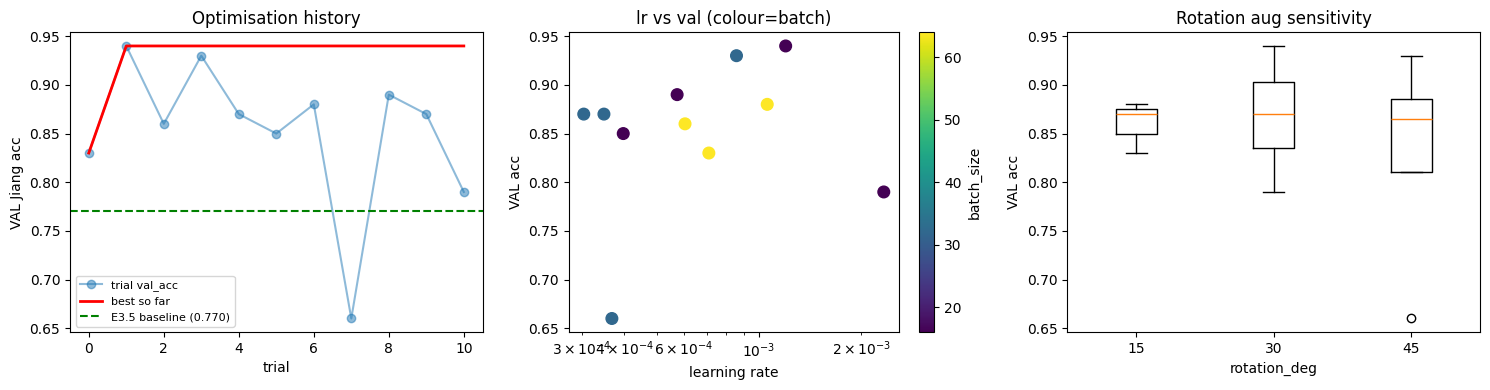

Hyperparameter importance (MeanDecreaseImpurity):
  weight_decay   0.419
  lr             0.373
  rotation_deg   0.109
  batch_size     0.099


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
order = sorted(_trial_log, key=lambda r: r['trial'])
vals = [r['val_acc'] for r in order]
best_so_far = np.maximum.accumulate(vals)
ax[0].plot([r['trial'] for r in order], vals, 'o-', alpha=0.5, label='trial val_acc')
ax[0].plot([r['trial'] for r in order], best_so_far, 'r-', lw=2, label='best so far')
ax[0].axhline(E35_ACC, color='green', ls='--', label=f'E3.5 baseline ({E35_ACC:.3f})')
ax[0].set(xlabel='trial', ylabel='VAL Jiang acc', title='Optimisation history')
ax[0].legend(fontsize=8)
sc = ax[1].scatter(trials_df['lr'], trials_df['val_acc'], c=trials_df['batch_size'],
                   cmap='viridis', s=70)
ax[1].set(xscale='log', xlabel='learning rate', ylabel='VAL acc', title='lr vs val (colour=batch)')
plt.colorbar(sc, ax=ax[1], label='batch_size')
rot_groups = [trials_df[trials_df['rotation_deg']==r]['val_acc'].values for r in [15,30,45]]
ax[2].boxplot(rot_groups, labels=['15','30','45'])
ax[2].set(xlabel='rotation_deg', ylabel='VAL acc', title='Rotation aug sensitivity')
plt.tight_layout()
plt.savefig(ROOT / 'results/phase4_optuna_search.png', dpi=110, bbox_inches='tight')
plt.show()
try:
    imp = optuna.importance.get_param_importances(study)
    print('Hyperparameter importance (MeanDecreaseImpurity):')
    for k, v in imp.items():
        print(f'  {k:14s} {v:.3f}')
except Exception as e:
    print('importance unavailable:', e)

## 4 - Tuned champion: retrain on full 785 and evaluate on TEST

The winning config is retrained on **FULL-TRAIN (785, incl. folder 07)** at `FINAL_EPOCHS=40` - identical training set
to Phase-3's E3.5, so the only differences are the tuned hyperparameters and the longer schedule. This is the one and
only time the tuned model sees the **test folder (03)**. `FINAL_EPOCHS=40` was fixed before any test number was seen;
the 25-epoch row is an honest ablation, not a cherry-pick.

In [8]:
results = {}
print(f'=== Tuned champion (best Optuna config) on FULL-TRAIN={len(full_train)} ===')
print(f'config: {best_cfg}')
for ep in [FINAL_EPOCHS, 25]:
    model_t, res_t = fit_e35(full_train, lr=best_cfg['lr'], wd=best_cfg['weight_decay'],
                             rot=best_cfg['rotation_deg'], bs=best_cfg['batch_size'], epochs=ep)
    m = evaluate_p3(model_t, test_set, use_depth_blue=True)
    key = f'P4_tuned_{ep}ep'
    m['train_seconds'] = res_t.train_seconds; m['train_curve'] = res_t.train_curve
    m['config'] = {**best_cfg, 'epochs': ep}
    results[key] = m
    tag = ' (champion, a-priori)' if ep == FINAL_EPOCHS else ' (ablation)'
    print(f'  {key}{tag}: test_acc={m["accuracy"]:.3f}  med_iou={m["median_iou"]:.3f}  '
          f'med_ang={m["median_angle_err_deg"]:.1f}  train={res_t.train_seconds:.0f}s')
    if ep == FINAL_EPOCHS:
        champion_model = model_t; champion = m

delta = champion['accuracy'] - E35_ACC
print(f'\nTuned champion ({FINAL_EPOCHS}ep) test_acc={champion["accuracy"]:.3f}  '
      f'vs E3.5 {E35_ACC:.3f}  ->  delta={delta:+.3f}')
print(f'vs Redmon 2015 obj-wise 0.849 -> gap now {0.849 - champion["accuracy"]:+.3f}')

=== Tuned champion (best Optuna config) on FULL-TRAIN=785 ===
config: {'lr': 0.0011973917635685037, 'weight_decay': 0.0002607024758370766, 'rotation_deg': 30, 'batch_size': 16}


  P4_tuned_40ep (champion, a-priori): test_acc=0.780  med_iou=0.445  med_ang=5.6  train=813s


  P4_tuned_25ep (ablation): test_acc=0.750  med_iou=0.404  med_ang=5.6  train=492s

Tuned champion (40ep) test_acc=0.780  vs E3.5 0.770  ->  delta=+0.010
vs Redmon 2015 obj-wise 0.849 -> gap now +0.069


## 4b - Did tuning move the needle? *(interpretation written after seeing the numbers in the report)*

## 5 - Depth as a genuine 4th channel (the Phase-3 hypothesis test)

Phase 3 concluded depth-as-blue hurt because **substituting** depth destroyed the blue colour channel. The clean test:
keep RGB intact, **append** depth as a 4th channel, re-init conv1 to 4 inputs (RGB filters copied from ImageNet, the
depth filter seeded from the mean RGB filter). Apples-to-apples comparison set, all at 20 epochs / lr=1e-3 / wd=1e-4 /
bs=32 / single-positive / **no rotation** (matching E3.1 and E3.3 exactly):

| run | depth | blue kept? | Phase-3 result |
|---|---|---|---|
| E3.1 | none | - | 0.730 |
| E3.3 | depth->blue | no | 0.710 |
| **P4 4-ch** | depth = ch4 | **yes** | *this experiment* |

If the 4-channel run lands **>= 0.730**, the depth signal *was* real and Phase-3's blue-channel-loss explanation is
confirmed. If it's ~0.71 or lower, depth genuinely doesn't help this binary metric. We also run a 4-ch *all-knobs*
variant (rotation + multi-positive) to see whether depth helps inside the full stack.

In [9]:
print('=== Depth-as-4th-channel experiments (FULL-TRAIN -> TEST) ===')
m4a, r4a = fit_e35(full_train, lr=1e-3, wd=1e-4, rot=0, bs=32, epochs=20,
                   depth_4ch=True, multi_pos=False)
res4a = evaluate_p3(m4a, test_set, use_depth_4ch=True)
res4a['train_seconds'] = r4a.train_seconds
results['P4_4ch_clean'] = res4a
print(f'  P4_4ch_clean (no rot, single-pos, 20ep): test_acc={res4a["accuracy"]:.3f}  '
      f'med_iou={res4a["median_iou"]:.3f}  (E3.1=0.730 none, E3.3=0.710 depth-blue)')

m4b, r4b = fit_e35(full_train, lr=1e-3, wd=1e-4, rot=30, bs=32, epochs=20,
                   depth_4ch=True, multi_pos=True)
res4b = evaluate_p3(m4b, test_set, use_depth_4ch=True)
res4b['train_seconds'] = r4b.train_seconds
results['P4_4ch_allknobs'] = res4b
print(f'  P4_4ch_allknobs (rot30, multi-pos, 20ep): test_acc={res4b["accuracy"]:.3f}  '
      f'med_iou={res4b["median_iou"]:.3f}  (E3.5 depth-blue all-knobs=0.770)')

print(f'\nDepth-channel verdict: 4ch_clean {res4a["accuracy"]:.3f} vs E3.1 0.730 (none) '
      f'vs E3.3 0.710 (depth-blue)')

=== Depth-as-4th-channel experiments (FULL-TRAIN -> TEST) ===


  P4_4ch_clean (no rot, single-pos, 20ep): test_acc=0.700  med_iou=0.402  (E3.1=0.730 none, E3.3=0.710 depth-blue)


  P4_4ch_allknobs (rot30, multi-pos, 20ep): test_acc=0.610  med_iou=0.324  (E3.5 depth-blue all-knobs=0.770)

Depth-channel verdict: 4ch_clean 0.700 vs E3.1 0.730 (none) vs E3.3 0.710 (depth-blue)


## 5b - Depth-channel interpretation *(written up in the report)*

## 6 - Image-wise split (direct comparison to published image-wise numbers)

The object-wise split (held-out *objects*) is the hard protocol. Published Cornell papers also report an **image-wise**
random 80/20 split, where an object can appear in both train and test - easier, higher numbers. We retrain the **E3.5
champion config** (the Phase-3 stack, 20 epochs) on a random 80/20 image-wise split so our number is directly comparable
to Lenz 2014 image-wise (0.756) and Redmon 2015 image-wise (0.844).

In [10]:
iw_train, iw_test = image_wise_split(samples, test_frac=0.2, seed=SEED)
print(f'image-wise split: train={len(iw_train)}  test={len(iw_test)}')
m_iw, r_iw = fit_e35(iw_train, lr=1e-3, wd=1e-4, rot=30, bs=32, epochs=20)  # E3.5 config
res_iw = evaluate_p3(m_iw, iw_test, use_depth_blue=True)
res_iw['train_seconds'] = r_iw.train_seconds
results['P4_imagewise_E35'] = res_iw
print(f'  E3.5-config image-wise: test_acc={res_iw["accuracy"]:.3f}  '
      f'med_iou={res_iw["median_iou"]:.3f}  n={res_iw["n"]}')
print(f'  refs: Lenz 2014 image-wise=0.756 | Redmon 2015 image-wise=0.844 | '
      f'our object-wise E3.5=0.770')

image-wise split: train=708  test=177


  E3.5-config image-wise: test_acc=0.757  med_iou=0.391  n=177
  refs: Lenz 2014 image-wise=0.756 | Redmon 2015 image-wise=0.844 | our object-wise E3.5=0.770


## 7 - Error analysis: where do the tuned champion's mistakes live?

We reload the saved Phase-3 E3.5 checkpoint, evaluate it on the test folder to recover its per-sample errors, and
decompose both models' failures into the three diagnostic buckets. Phase 3's dominant cluster was **angle-ok /
IoU-too-low** (the box points the right way but is mislocated). Has tuning shifted that?

In [11]:
e35 = ResNet18Regressor(out_dim=6, pretrained=False).to(DEVICE)
e35.load_state_dict(torch.load(ROOT / 'models/E3.5_all_knobs_phase3.pt', map_location=DEVICE))
e35_eval = evaluate_p3(e35, test_set, use_depth_blue=True)
print(f'reloaded E3.5 checkpoint -> test_acc={e35_eval["accuracy"]:.3f} '
      f'(metrics.json recorded {E35_ACC:.3f})')

dec_e35  = failure_decompose(e35_eval['per_sample'])
dec_tune = failure_decompose(champion['per_sample'])
buckets = ['angle_ok_iou_low', 'iou_ok_angle_wrong', 'both_wrong']
print('\nFailure decomposition (count of wrong predictions on 100 test images):')
decomp_df = pd.DataFrame({
    'bucket': buckets,
    'E3.5 (0.770)': [dec_e35.get(b, 0) for b in buckets],
    f'Tuned champion ({champion["accuracy"]:.3f})': [dec_tune.get(b, 0) for b in buckets],
})
print(decomp_df.to_string(index=False))
decomp_df.to_csv(ROOT / 'results/phase4_failure_decomposition.csv', index=False)

reloaded E3.5 checkpoint -> test_acc=0.770 (metrics.json recorded 0.770)

Failure decomposition (count of wrong predictions on 100 test images):
            bucket  E3.5 (0.770)  Tuned champion (0.780)
  angle_ok_iou_low            14                      10
iou_ok_angle_wrong             3                       6
        both_wrong             6                       6


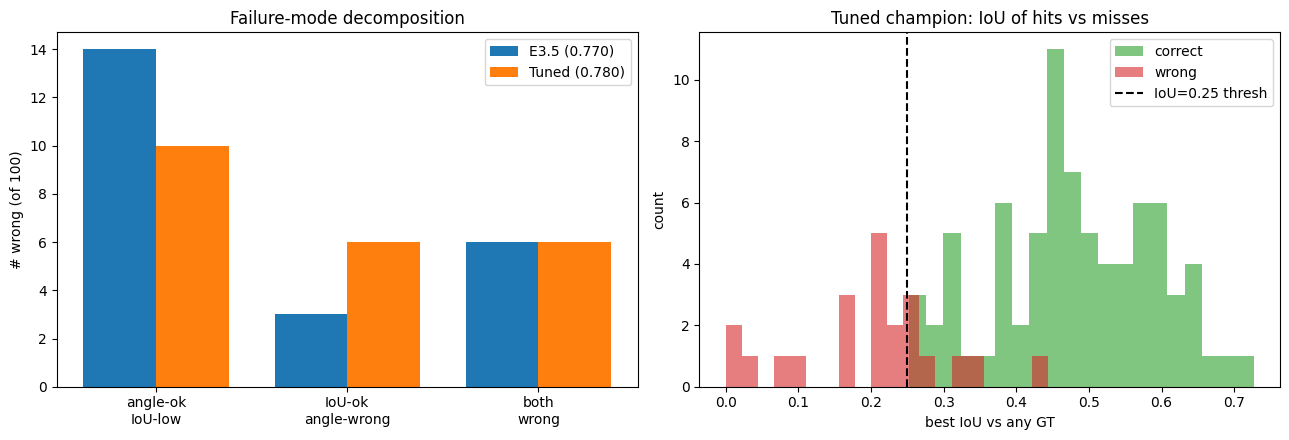

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(buckets)); w = 0.38
ax[0].bar(x - w/2, [dec_e35.get(b,0) for b in buckets], w, label=f'E3.5 ({e35_eval["accuracy"]:.3f})')
ax[0].bar(x + w/2, [dec_tune.get(b,0) for b in buckets], w,
          label=f'Tuned ({champion["accuracy"]:.3f})')
ax[0].set_xticks(x); ax[0].set_xticklabels(['angle-ok\nIoU-low','IoU-ok\nangle-wrong','both\nwrong'])
ax[0].set(ylabel='# wrong (of 100)', title='Failure-mode decomposition')
ax[0].legend()
ps = champion['per_sample']
ious_ok  = [r['best_iou'] for r in ps if r['correct']]
ious_bad = [r['best_iou'] for r in ps if not r['correct']]
ax[1].hist(ious_ok, bins=20, alpha=0.6, label='correct', color='tab:green')
ax[1].hist(ious_bad, bins=20, alpha=0.6, label='wrong', color='tab:red')
ax[1].axvline(0.25, color='black', ls='--', label='IoU=0.25 thresh')
ax[1].set(xlabel='best IoU vs any GT', ylabel='count', title='Tuned champion: IoU of hits vs misses')
ax[1].legend()
plt.tight_layout()
plt.savefig(ROOT / 'results/phase4_failure_decomposition.png', dpi=110, bbox_inches='tight')
plt.show()

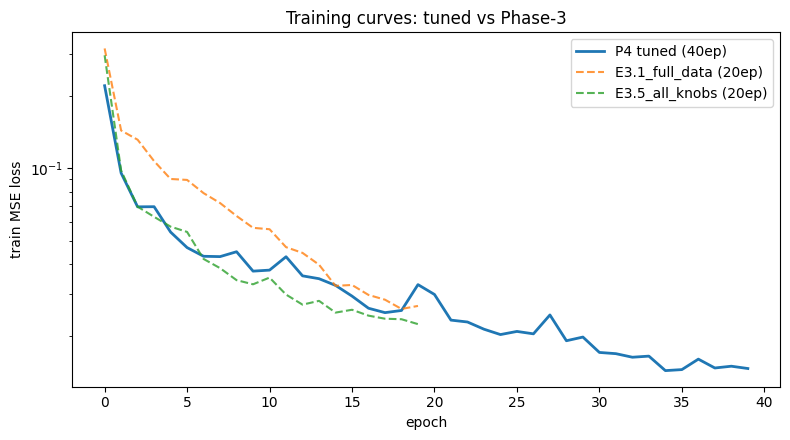

final train loss -> tuned: 0.0147


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(champion['train_curve'], label=f'P4 tuned ({FINAL_EPOCHS}ep)', lw=2)
for name in ['E3.1_full_data', 'E3.5_all_knobs']:
    tc = M['phase_3']['experiments'][name].get('train_curve')
    if tc:
        ax.plot(tc, '--', alpha=0.8, label=f'{name} (20ep)')
ax.set(xlabel='epoch', ylabel='train MSE loss', title='Training curves: tuned vs Phase-3', yscale='log')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'results/phase4_training_curves.png', dpi=110, bbox_inches='tight')
plt.show()
print('final train loss -> tuned:', f"{champion['train_curve'][-1]:.4f}")

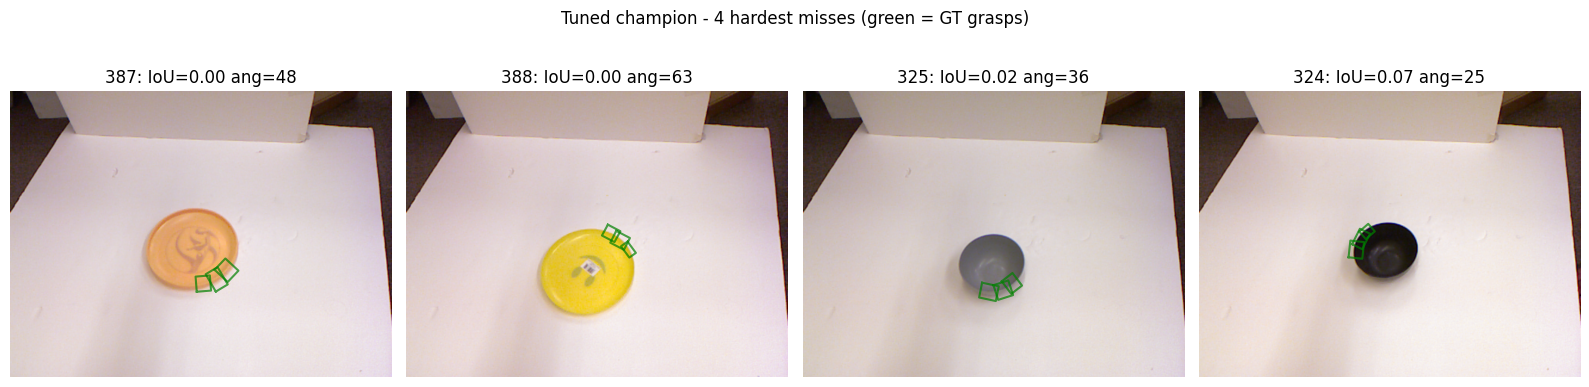

In [14]:
from PIL import Image
worst = sorted(champion['per_sample'], key=lambda r: r['best_iou'])[:4]
id2s = {s.pcd_id: s for s in test_set}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, rec in zip(axes, worst):
    s = id2s[rec['pcd_id']]
    img = Image.open(s.rgb_path).convert('RGB')
    ax.imshow(img)
    for g in s.positives[:3]:
        c = np.vstack([g.corners, g.corners[0]])
        ax.plot(c[:,0], c[:,1], 'g-', lw=1.5, alpha=0.7)
    ax.set_title(f"{s.pcd_id}: IoU={rec['best_iou']:.2f} ang={rec['best_angle_err']:.0f}")
    ax.axis('off')
fig.suptitle('Tuned champion - 4 hardest misses (green = GT grasps)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'results/phase4_champion_qualitative.png', dpi=110, bbox_inches='tight')
plt.show()

## 8 - Consolidated leaderboard

OBJECT-WISE leaderboard:
                         model   acc                                                                                                       note
                 Cao 2023 SOTA 0.978                                                                                                  published
                   Redmon 2015 0.849                                                                                                  published
       P4 tuned (40ep, Optuna) 0.780 {'lr': 0.0011973917635685037, 'weight_decay': 0.0002607024758370766, 'rotation_deg': 30, 'batch_size': 16}
E3.5 all-knobs (Phase-3 champ) 0.770                                                                                    rot+depth-blue+multipos
                     Lenz 2014 0.739                                                                                                  published
        E3.1 full-data control 0.730                                                                           

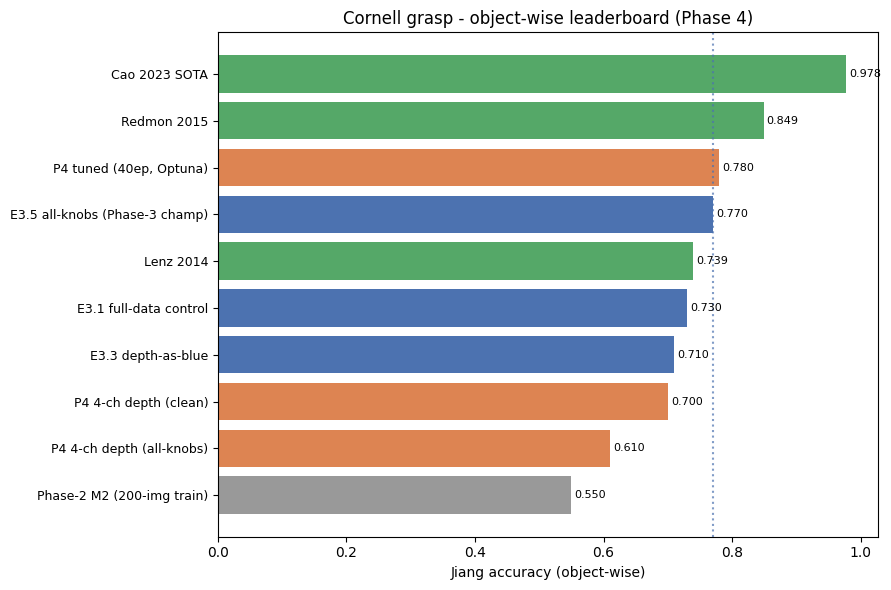

In [15]:
rows = [
    {'rank_grp':'phase2', 'model':'Phase-2 M2 (200-img train)', 'acc':P2_M2, 'split':'object', 'note':'data-starved ceiling'},
    {'rank_grp':'phase3', 'model':'E3.1 full-data control', 'acc':p3['E3.1_full_data']['accuracy'], 'split':'object', 'note':'no depth, no rot'},
    {'rank_grp':'phase3', 'model':'E3.3 depth-as-blue', 'acc':p3['E3.3_depth_blue']['accuracy'], 'split':'object', 'note':'blue replaced'},
    {'rank_grp':'phase3', 'model':'E3.5 all-knobs (Phase-3 champ)', 'acc':E35_ACC, 'split':'object', 'note':'rot+depth-blue+multipos'},
    {'rank_grp':'phase4', 'model':f'P4 tuned ({FINAL_EPOCHS}ep, Optuna)', 'acc':champion['accuracy'], 'split':'object', 'note':str(best_cfg)},
    {'rank_grp':'phase4', 'model':'P4 4-ch depth (clean)', 'acc':results['P4_4ch_clean']['accuracy'], 'split':'object', 'note':'depth=ch4, no rot, single-pos'},
    {'rank_grp':'phase4', 'model':'P4 4-ch depth (all-knobs)', 'acc':results['P4_4ch_allknobs']['accuracy'], 'split':'object', 'note':'depth=ch4 + rot + multipos'},
    {'rank_grp':'phase4', 'model':'P4 E3.5-config image-wise', 'acc':results['P4_imagewise_E35']['accuracy'], 'split':'image', 'note':'random 80/20'},
    {'rank_grp':'ref', 'model':'Lenz 2014', 'acc':0.739, 'split':'object', 'note':'published'},
    {'rank_grp':'ref', 'model':'Lenz 2014', 'acc':0.756, 'split':'image', 'note':'published'},
    {'rank_grp':'ref', 'model':'Redmon 2015', 'acc':0.849, 'split':'object', 'note':'published'},
    {'rank_grp':'ref', 'model':'Redmon 2015', 'acc':0.844, 'split':'image', 'note':'published'},
    {'rank_grp':'ref', 'model':'Cao 2023 SOTA', 'acc':0.978, 'split':'object', 'note':'published'},
]
lb = pd.DataFrame(rows)
lb_obj = lb[lb['split']=='object'].sort_values('acc', ascending=False).reset_index(drop=True)
print('OBJECT-WISE leaderboard:')
print(lb_obj[['model','acc','note']].to_string(index=False))
lb.to_csv(ROOT / 'results/phase4_leaderboard.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {'phase2':'#999999','phase3':'#4c72b0','phase4':'#dd8452','ref':'#55a868'}
d = lb_obj
ax.barh(range(len(d)), d['acc'], color=[colors[g] for g in d['rank_grp']])
ax.set_yticks(range(len(d))); ax.set_yticklabels(d['model'], fontsize=9)
ax.invert_yaxis(); ax.set(xlabel='Jiang accuracy (object-wise)', title='Cornell grasp - object-wise leaderboard (Phase 4)')
ax.axvline(E35_ACC, color='#4c72b0', ls=':', alpha=0.7)
for i, a in enumerate(d['acc']): ax.text(a+0.005, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'results/phase4_leaderboard.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 - Persist results

In [16]:
def _slim(d):
    return {k:v for k,v in d.items() if k not in ('per_sample',)}
M['phase_4'] = {
    'date': '2026-05-28',
    'task': 'Hyperparameter tuning (Optuna) + error analysis on the E3.5 stack',
    'metric_primary': 'Jiang IoU > 0.25 AND angle err < 30 deg',
    'protocol': {'test_folders': TEST_FOLDERS, 'val_folders': VAL_FOLDERS,
                 'n_search_train': len(search_train), 'n_full_train': len(full_train),
                 'n_test': len(test_set), 'proxy_epochs': PROXY_EPOCHS,
                 'final_epochs': FINAL_EPOCHS, 'n_trials': len(study.trials)},
    'optuna_best_params': best_cfg, 'optuna_best_val_acc': study.best_value,
    'baseline_e35_obj_test': E35_ACC,
    'tuned_champion': {'acc': champion['accuracy'], 'median_iou': champion['median_iou'],
                       'median_angle_err_deg': champion['median_angle_err_deg'],
                       'delta_vs_e35': champion['accuracy'] - E35_ACC,
                       'config': champion['config']},
    'experiments': {k: _slim(v) for k, v in results.items()},
    'failure_decomposition': {'E3.5': dec_e35, 'tuned': dec_tune},
}
metrics_path.write_text(json.dumps(M, indent=2))
print('updated results/metrics.json with phase_4 block (phases present:',
      [k for k in M if k.startswith('phase_')], ')')

ckpt = ROOT / 'models/P4_tuned_champion.pt'
torch.save(champion_model.state_dict(), ckpt)
print(f'saved {ckpt.name} ({ckpt.stat().st_size/1e6:.1f} MB)')

headline = {
    'tuned_vs_e35': {'tuned': champion['accuracy'], 'e35': E35_ACC,
                     'delta': champion['accuracy'] - E35_ACC},
    'depth_channel_test': {'none_E3.1': 0.730, 'depth_blue_E3.3': 0.710,
                           'depth_4ch_clean': results['P4_4ch_clean']['accuracy']},
    'image_wise': {'ours_E35cfg': results['P4_imagewise_E35']['accuracy'],
                   'lenz_2014': 0.756, 'redmon_2015': 0.844},
}
(ROOT / 'results/phase4_headline_summary.json').write_text(json.dumps(headline, indent=2))
print(json.dumps(headline, indent=2))

updated results/metrics.json with phase_4 block (phases present: ['phase_1', 'phase_2', 'phase_3', 'phase_4'] )


saved P4_tuned_champion.pt (44.8 MB)
{
  "tuned_vs_e35": {
    "tuned": 0.78,
    "e35": 0.77,
    "delta": 0.010000000000000009
  },
  "depth_channel_test": {
    "none_E3.1": 0.73,
    "depth_blue_E3.3": 0.71,
    "depth_4ch_clean": 0.7
  },
  "image_wise": {
    "ours_E35cfg": 0.7570621468926554,
    "lenz_2014": 0.756,
    "redmon_2015": 0.844
  }
}


In [17]:
log_path = ROOT / 'results/EXPERIMENT_LOG.md'
existing = log_path.read_text() if log_path.exists() else ''
L = ['', '## Phase 4 - Optuna tuning + error analysis (2026-05-28)', '']
L.append(f'Protocol: object-wise. TEST=folder 03 (n={len(test_set)}), VAL=folder 07 (Optuna objective), '
         f'SEARCH-TRAIN={len(search_train)}, FULL-TRAIN={len(full_train)}. '
         f'Optuna: {len(study.trials)} trials, {PROXY_EPOCHS}-epoch proxy, TPESampler(seed=42).')
L.append('')
L.append(f'**Best config:** `{best_cfg}` (val_acc={study.best_value:.3f}).')
L.append('')
L.append('| Experiment | Split | Accuracy | delta vs E3.5 (0.770) | Median IoU |')
L.append('|---|---|---:|---:|---:|')
def _row(name, label, split):
    v = results[name]; return (f'| {label} | {split} | {v["accuracy"]:.3f} | '
                               f'{v["accuracy"]-E35_ACC:+.3f} | {v["median_iou"]:.3f} |')
L.append(_row('P4_tuned_40ep', f'P4 tuned ({FINAL_EPOCHS}ep)', 'object'))
L.append(_row('P4_tuned_25ep', 'P4 tuned (25ep, ablation)', 'object'))
L.append(_row('P4_4ch_clean', 'P4 4-ch depth (clean)', 'object'))
L.append(_row('P4_4ch_allknobs', 'P4 4-ch depth (all-knobs)', 'object'))
L.append(_row('P4_imagewise_E35', 'P4 E3.5-cfg image-wise', 'image'))
L.append('')
L.append(f'Failure decomposition (wrong/100): E3.5={dec_e35}, tuned={dec_tune}.')
log_path.write_text(existing + '\n'.join(L) + '\n')
print('appended Phase 4 to EXPERIMENT_LOG.md')
print('\n'.join(L))

appended Phase 4 to EXPERIMENT_LOG.md

## Phase 4 - Optuna tuning + error analysis (2026-05-28)

Protocol: object-wise. TEST=folder 03 (n=100), VAL=folder 07 (Optuna objective), SEARCH-TRAIN=685, FULL-TRAIN=785. Optuna: 11 trials, 15-epoch proxy, TPESampler(seed=42).

**Best config:** `{'lr': 0.0011973917635685037, 'weight_decay': 0.0002607024758370766, 'rotation_deg': 30, 'batch_size': 16}` (val_acc=0.940).

| Experiment | Split | Accuracy | delta vs E3.5 (0.770) | Median IoU |
|---|---|---:|---:|---:|
| P4 tuned (40ep) | object | 0.780 | +0.010 | 0.445 |
| P4 tuned (25ep, ablation) | object | 0.750 | -0.020 | 0.404 |
| P4 4-ch depth (clean) | object | 0.700 | -0.070 | 0.402 |
| P4 4-ch depth (all-knobs) | object | 0.610 | -0.160 | 0.324 |
| P4 E3.5-cfg image-wise | image | 0.757 | -0.013 | 0.391 |

Failure decomposition (wrong/100): E3.5={'angle_ok_iou_low': 14, 'iou_ok_angle_wrong': 3, 'both_wrong': 6}, tuned={'angle_ok_iou_low': 10, 'iou_ok_angle_wrong': 6, 'both_wrong': 6}.


## 10 - Headline findings

*(The narrative interpretation - what beat what and why - is written up in `reports/day4_phase4_report.md` and
`PROGRESS_LOG.md` after the run, citing the exact numbers produced above. The notebook is the experiment; the report
is the story.)*